# Import Required Libraries

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import config
from tqdm import tqdm
from myloss import myLoss
from sigdatasets import myDatasetNew
import ucds
import random
import models.NeuMF as NeuMF


# Define Basic Configurations

In [15]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SPLIT = "=" * 60
L2 = 1e-5


# Define Training Functions and Result Logging

In [16]:
original_my_loss_values = []
fair_my_loss_values = []

# Train function
def train_InUCDS(epoch):
    print(SPLIT)
    print(f"Train epoch: {epoch}")
    original_loss_list = [[], [], []]   #[total,bce,my_loss]
    fair_loss_list = [[], [], []]       #[total,bce,my_loss]
    for batch_idx, data in tqdm(enumerate(sample_generator)):
        users, items, rating = data[0].to(device), data[1].to(device), data[2].to(device)

        model_original.train()
        model_fair.train()
        original_model_opt.zero_grad()
        fair_model_opt.zero_grad()
        # ----------------------------------------------------
        # train original model
        original_model_predict = model_original(users, items)

        original_model_bce_loss = bce_loss(original_model_predict.view(-1), rating)

        inactive_embedding_samples_original = model_original.inactive_embeddings_for_my_loss(samples)
        neighbor_embedding_samples_original = model_original.neighbor_embeddings_for_my_loss(samples)


        original_model_my_loss = my_loss(inactive_embedding_samples_original, neighbor_embedding_samples_original)

        original_model_loss = original_model_bce_loss
        original_loss_list[0].append(original_model_loss.item())
        original_loss_list[1].append(original_model_bce_loss.item())
        original_loss_list[2].append(original_model_my_loss.item())

        original_model_loss.backward()
        original_model_opt.step()
        # ----------------------------------------------------
        # train fair model
        fair_model_predict = model_fair(users, items)
        fair_model_bce_loss = bce_loss(fair_model_predict.view(-1), rating)


        inactive_embedding_samples = model_fair.inactive_embeddings_for_my_loss(samples)
        neighbor_embedding_samples = model_fair.neighbor_embeddings_for_my_loss(samples)


        fair_model_my_loss = my_loss(inactive_embedding_samples, neighbor_embedding_samples)

        fair_model_loss = fair_model_bce_loss + fair_model_my_loss
        fair_loss_list[0].append(fair_model_loss.item())
        fair_loss_list[1].append(fair_model_bce_loss.item())
        fair_loss_list[2].append(fair_model_my_loss.item())

        fair_model_loss.backward()
        fair_model_opt.step()
    print(f"Orin loss: {round(np.mean(original_loss_list[0]), 4)}, "
          f"BCE loss: {round(np.mean(original_loss_list[1]), 4)}, "
          f"my loss: {round(np.mean(original_loss_list[2]), 4)},")
    print(f"Fair loss: {round(np.mean(fair_loss_list[0]), 4)}, "
          f"BCE loss: {round(np.mean(fair_loss_list[1]), 4)}, "
          f"my loss: {round(np.mean(fair_loss_list[2]), 4)},")

    original_my_loss_values.append(np.mean(original_loss_list[2]))
    fair_my_loss_values.append(np.mean(fair_loss_list[2]))

# Set Up and Load the Dataset

In [17]:
# Dataset configurations
datasets = ["Epinion", "MovieLens", "Gowalla"]
loss_values = {}
config = config.neumf_config
bce_loss = torch.nn.BCELoss()
my_loss = myLoss(l2=L2)

for dataset_name in datasets:
    args = {
        'no_cuda': False,
        'seed': 10,
        'epochs': 100,
        'model': "NeuMF",
        'cuda_index': 1,
        'dataset': dataset_name,
        'split': "count",
        'random_seed': 42,
        'neighbor_num': 3,
        'log': f'logs/{dataset_name}',
        'model_time': 0
    }


    set_seed(args['seed'])
    device = torch.device(f"cuda:{args['cuda_index']}" if torch.cuda.is_available() else "cpu")

    result_dir = os.path.join("result", dataset_name)
    if not os.path.exists(result_dir):
        os.mkdir(result_dir)
    result_dir = os.path.join(result_dir, args['model'])
    if not os.path.exists(result_dir):
        os.mkdir(result_dir)
    print(f"Training on {dataset_name} dataset...")
    dataset = myDatasetNew(dataset=args['dataset'], train_neg_num=config["num_negative"],
                           neighbor_num=args['neighbor_num'], result_path=result_dir)
    user_num, item_num, active_users, inactive_users = dataset.get_statistic()
    similarity_matrix = dataset.get_user_similarity_matrix()
    # UCDS Modeling
    InUCDS = ucds.InUCDS(num_users=user_num, active_ids=active_users, inactive_ids=inactive_users,
                         similarity_matrix=similarity_matrix)
    samples = InUCDS.generate_dominant_sets_for_all_inactive(neighbor_num=args['neighbor_num'])

    dataset = myDatasetNew(dataset=dataset_name, train_neg_num=config["num_negative"],
                           neighbor_num=args['neighbor_num'], result_path=result_dir)

    model_dic = {
        'NeuMF': NeuMF.NeuMF
    }
    model_class = model_dic[args['model']]
    model_original = model_class(config, user_num, item_num, device=device)
    model_fair = model_class(config, user_num, item_num, device=device)

    model_original.to(device)
    model_fair.to(device)
    original_model_opt = torch.optim.Adam(model_original.parameters(),
                                          lr=config['adam_lr'],
                                          weight_decay=config['l2_regularization'])
    fair_model_opt = torch.optim.Adam(model_fair.parameters(),
                                      lr=config['adam_lr'],
                                      weight_decay=config['l2_regularization'])

    sample_generator = dataset.instance_a_train_loader(config['batch_size'])

    # Run training for each dataset
    original_my_loss_values.clear()
    fair_my_loss_values.clear()

    for epoch in range(args['epochs']):
        train_InUCDS(epoch)

    loss_values[dataset_name] = {
        'original': original_my_loss_values,
        'fair': fair_my_loss_values
    }

Training on Epinion dataset...
Load train, tune, test set...


100%|██████████| 20714/20714 [00:00<00:00, 1026317.00it/s]


xxx


100%|██████████| 103567/103567 [00:00<00:00, 819519.98it/s]


Get negative item pool...
Find similar users...
Extract 3 active neighbors for each inactive user.
Number of users: 2677, number of items: 2060
Number of interactions: 103567, sparsity = 98.12%
Load train, tune, test set...


...

Orin loss: 0.4399, BCE loss: 0.4399, my loss: 0.6238,
Fair loss: 0.7879, BCE loss: 0.4201, my loss: 0.3678,
Train epoch: 98


227it [00:02, 76.34it/s]


Orin loss: 0.4391, BCE loss: 0.4391, my loss: 0.6198,
Fair loss: 0.7837, BCE loss: 0.4184, my loss: 0.3653,
Train epoch: 99


227it [00:03, 75.01it/s]

Orin loss: 0.4383, BCE loss: 0.4383, my loss: 0.616,
Fair loss: 0.7797, BCE loss: 0.4167, my loss: 0.3629,


# Plot the Loss Curve

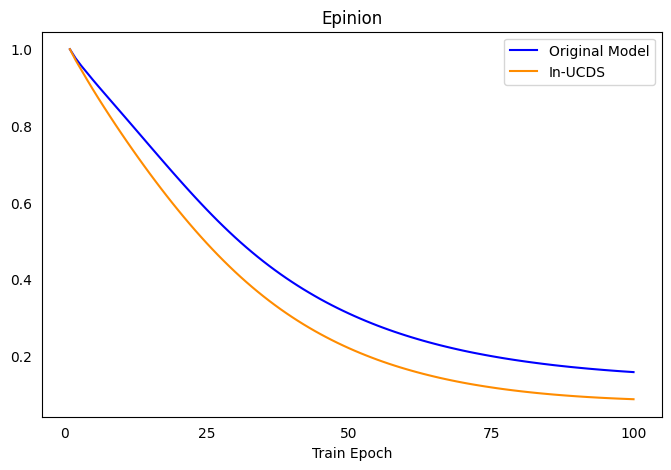

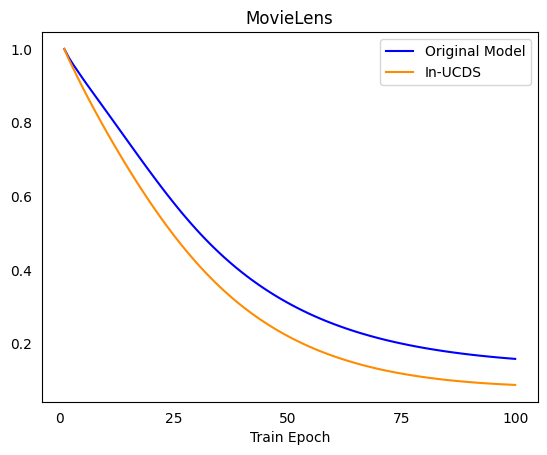

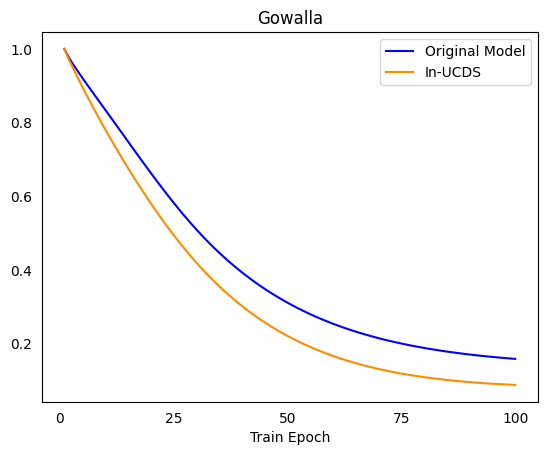

In [18]:
plt.figure(figsize=(8, 5))

for dataset_name in datasets:

    original_loss = loss_values[dataset_name]['original']
    fair_loss = loss_values[dataset_name]['fair']
    
    original_loss_normalized = original_loss / np.max(original_loss)
    fair_loss_normalized = fair_loss / np.max(fair_loss)
    
    plt.plot(range(1, args['epochs'] + 1), original_loss_normalized, color='blue', label='Original Model')
    plt.plot(range(1, args['epochs'] + 1), fair_loss_normalized, color='darkorange', label='In-UCDS')

    plt.title(f'{dataset_name}')

    plt.xlabel('Train Epoch')
    plt.legend()
    plt.grid(False)

    plt.xticks([0, 25, 50, 75, 100])
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1])

    plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False)

    plt.savefig(f"{dataset_name}.png")

    plt.show()
